In [13]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# Read NumPy data
infile_dir = 'graph_data'
data = np.load(infile_dir + '/cosmics_segment_test_data.npz')

print("Successfully loaded data!")

Successfully loaded data!


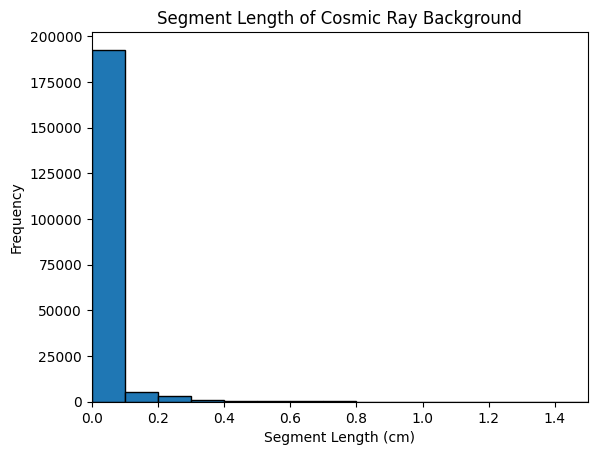

In [16]:
# Segment length plot

# Define bins
bins = np.arange(0, 1.6, 0.1)
plt.hist(data['lengths'], bins=bins, edgecolor='black')
plt.xlim(0, 1.5)

# Axis labels
plt.xlabel('Segment Length (cm)')
plt.ylabel('Frequency')
plt.title('Segment Length of Cosmic Ray Background')

plt.show()

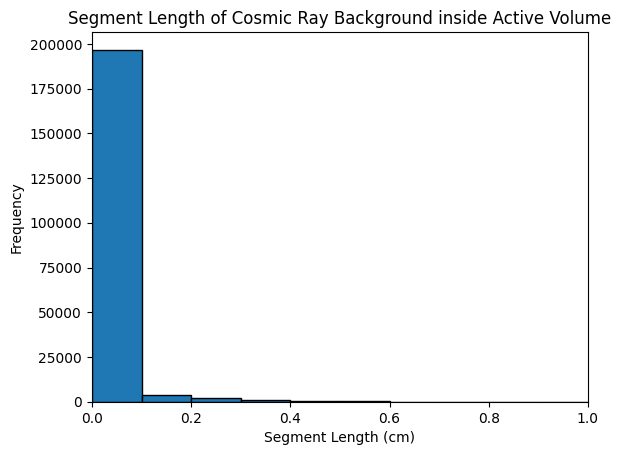

In [17]:
# Inside active volume

# Define bins
bins = np.arange(0, 1.1, 0.1)
plt.hist(data['in_active_volume'], bins=bins, edgecolor='black')
plt.xlim(0, 1)

# Axis labels
plt.xlabel('Segment Length (cm)')
plt.ylabel('Frequency')
plt.title('Segment Length of Cosmic Ray Background inside Active Volume')

plt.show()

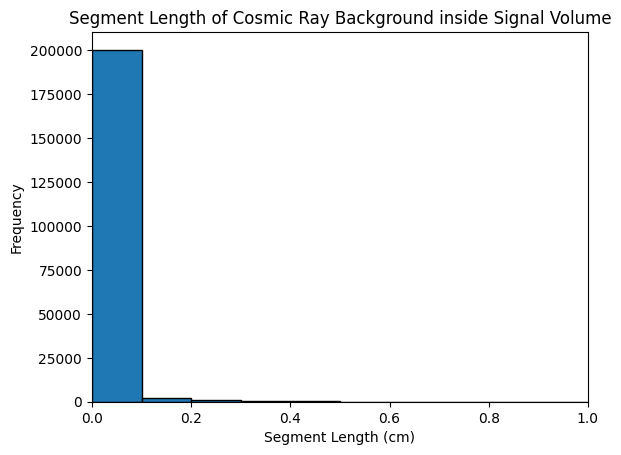

In [18]:
# Inside signal volume

# Define bins
bins = np.arange(0, 1.1, 0.1)
plt.hist(data['in_signal_volume'], bins=bins, edgecolor='black')
plt.xlim(0, 1)

# Axis labels
plt.xlabel('Segment Length (cm)')
plt.ylabel('Frequency')
plt.title('Segment Length of Cosmic Ray Background inside Signal Volume')

plt.show()

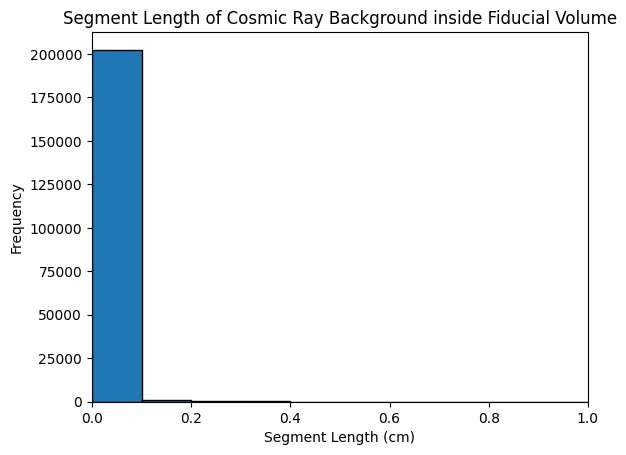

In [19]:
# Inside fiducial volume

# Define bins
bins = np.arange(0, 1.1, 0.1)
plt.hist(data['in_fiducial_volume'], bins=bins, edgecolor='black')
plt.xlim(0, 1)

# Axis labels
plt.xlabel('Segment Length (cm)')
plt.ylabel('Frequency')
plt.title('Segment Length of Cosmic Ray Background inside Fiducial Volume')

plt.show()

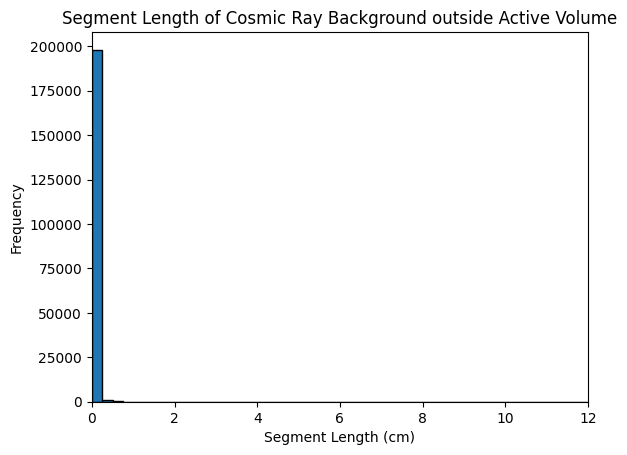

In [20]:
# Outside active volume

# Define bins
bins = np.arange(0, 12.25, 0.25)
plt.hist(data['outside_active_volume'], bins=bins, edgecolor='black')
plt.xlim(0, 12)

# Axis labels
plt.xlabel('Segment Length (cm)')
plt.ylabel('Frequency')
plt.title('Segment Length of Cosmic Ray Background outside Active Volume')

plt.show()

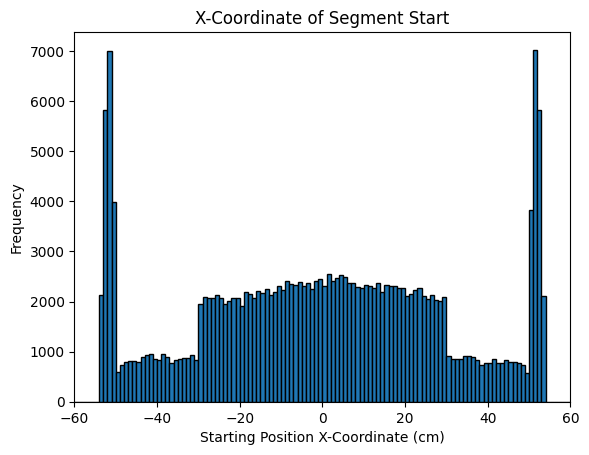

In [21]:
# X-start length plot

# Define bins
bins = np.arange(-60, 61, 1)
plt.hist(data['x_start'], bins=bins, edgecolor='black')
plt.xlim(-60, 60)

# Axis labels
plt.xlabel('Starting Position X-Coordinate (cm)')
plt.ylabel('Frequency')
plt.title('X-Coordinate of Segment Start')

plt.show()

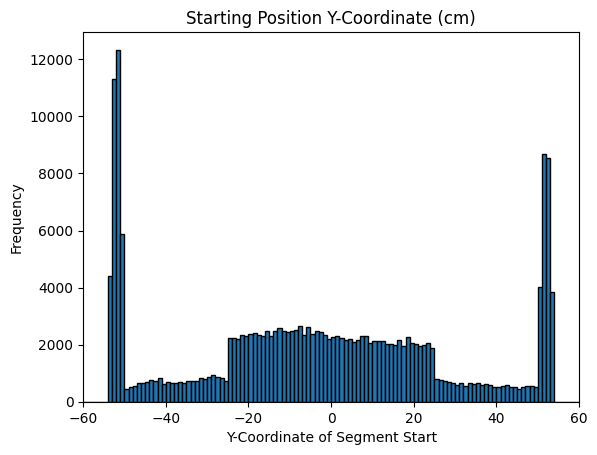

In [22]:
# Y-start length plot

# Define bins
bins = np.arange(-60, 61, 1)
plt.hist(data['y_start'], bins=bins, edgecolor='black')
plt.xlim(-60, 60)

# Axis labels
plt.xlabel('Y-Coordinate of Segment Start')
plt.ylabel('Frequency')
plt.title('Starting Position Y-Coordinate (cm)')

plt.show()

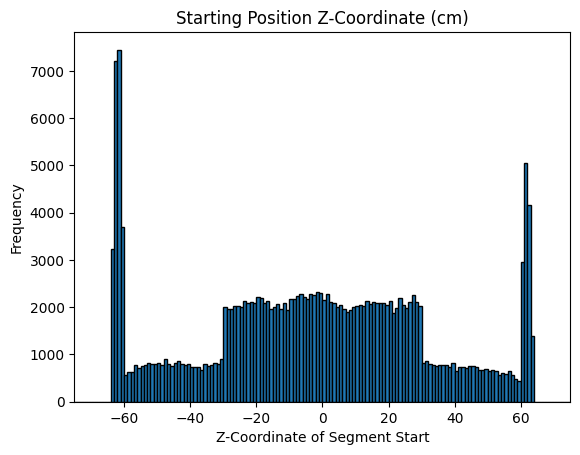

In [23]:
# Z-start length plot

# Define bins
bins = np.arange(-75, 76, 1)
plt.hist(data['z_start'], bins=bins, edgecolor='black')
plt.xlim(-75, 75)

# Axis labels
plt.xlabel('Z-Coordinate of Segment Start')
plt.ylabel('Frequency')
plt.title('Starting Position Z-Coordinate (cm)')

plt.show()

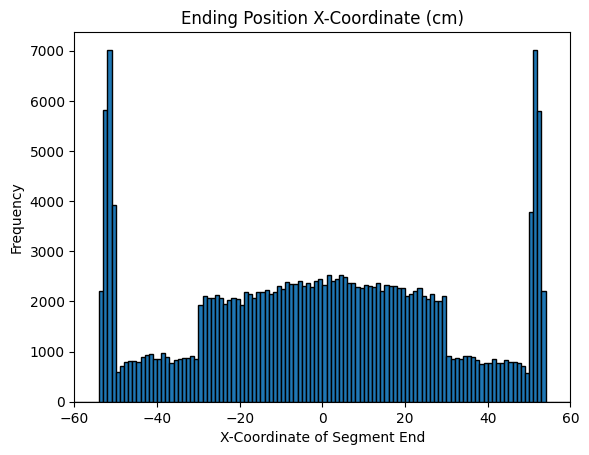

In [24]:
# X-end length plot

# Define bins
bins = np.arange(-60, 61, 1)
plt.hist(data['x_end'], bins=bins, edgecolor='black')
plt.xlim(-60, 60)

# Axis labels
plt.xlabel('X-Coordinate of Segment End')
plt.ylabel('Frequency')
plt.title('Ending Position X-Coordinate (cm)')

plt.show()

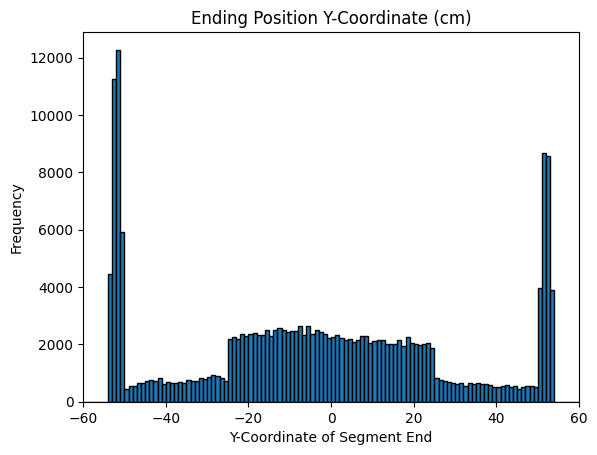

In [25]:
# Y-end length plot

# Define bins
bins = np.arange(-60, 61, 1)
plt.hist(data['y_end'], bins=bins, edgecolor='black')
plt.xlim(-60, 60)

# Axis labels
plt.xlabel('Y-Coordinate of Segment End')
plt.ylabel('Frequency')
plt.title('Ending Position Y-Coordinate (cm)')

plt.show()

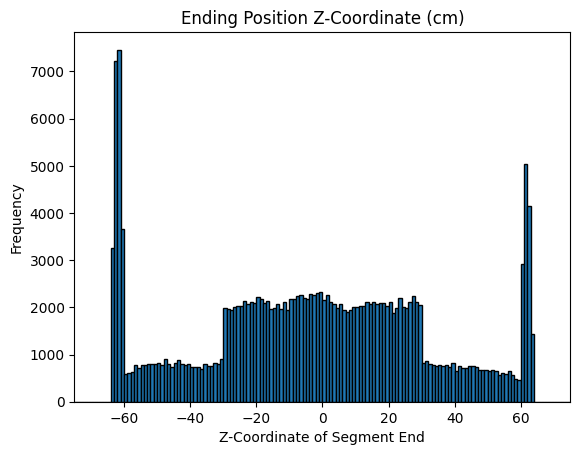

In [26]:
# Z-end length plot

# Define bins
bins = np.arange(-75, 76, 1)
plt.hist(data['z_end'], bins=bins, edgecolor='black')
plt.xlim(-75, 75)

# Axis labels
plt.xlabel('Z-Coordinate of Segment End')
plt.ylabel('Frequency')
plt.title('Ending Position Z-Coordinate (cm)')

plt.show()

In [24]:
from ROOT import TFile, TG4Event, TMap

tFile = TFile('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/Cosmics/CosmicFlux_g4_0000.root')

# Get the event tree.
events = tFile.Get("EDepSimEvents")

# Set the branch address.
event = ROOT.TG4Event()
events.SetBranchAddress("Event",ROOT.AddressOf(event))

4

In [74]:
for i in range(100):
    events.GetEntry(i)

    for containerName, hitSegments in event.SegmentDetectors:
        print(event.SegmentDetectors)
        if containerName.find("CRT") == -1:
            print(event.SegmentDetectors)

{ "CRTbottom" => { @0x55657c28b4d0 } }
{ "CRTbottom" => { @0x55657c5588a0 }, "CRTleft" => { @0x55657926f020, @0x55657926f0d8, @0x55657926f190, @0x55657926f248, @0x55657926f300, @0x55657926f3b8, @0x55657926f470, @0x55657926f528, @0x55657926f5e0, @0x55657926f698, @0x55657926f750, @0x55657926f808, @0x55657926f8c0, @0x55657926f978 } }
{ "CRTbottom" => { @0x55657c5588a0 }, "CRTleft" => { @0x55657926f020, @0x55657926f0d8, @0x55657926f190, @0x55657926f248, @0x55657926f300, @0x55657926f3b8, @0x55657926f470, @0x55657926f528, @0x55657926f5e0, @0x55657926f698, @0x55657926f750, @0x55657926f808, @0x55657926f8c0, @0x55657926f978 } }
{ "CRTright" => { @0x55657b1fd960 } }


In [75]:
from helper_functions import get_length_in_active_volume, get_length_in_signal_volume, get_length_in_fiducial_volume

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/BRN/BRN_g4_0000.h5', 'r')
print(f['trajectories'].dtype)

{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_process', 'start_subprocess', 'end_process', 'end_subprocess', 'dist_travel'], 'formats': ['<u4', '<u8', '<u8', '<i4', '<u4', '<i4', '?', '<f4', ('<f4', (3,)), ('<f4', (3,)), '<f8', '<f4', ('<f4', (3,)), ('<f4', (3,)), '<f8', '<i4', '<i4', '<i4', '<i4', '<i4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 56, 72, 80, 84, 96, 112, 120, 124, 128, 132, 136, 140], 'itemsize': 144}


In [76]:
data_traj = []
data_evttraj = []
data_trajid = []
for traj in f['trajectories']:
    data_traj.append(get_length_in_active_volume(traj['xyz_start'][0], traj['xyz_end'][0], traj['xyz_start'][1], traj['xyz_end'][1], traj['xyz_start'][2], traj['xyz_end'][2]))
    data_evttraj.append(traj['event_id'])
    data_trajid.append(traj['traj_id'])

In [82]:
j = 0
for i, k in enumerate(data_traj):
    if k != 0:
        j += 1
        print("Event ID: " + str(data_evttraj[i]) + ", Trajectory ID: " + str(data_trajid[i]) + ", Length in Active Volume: " + str(k))

print(j)

Event ID: 1, Trajectory ID: 0, Length in Active Volume: 9.385078
Event ID: 1, Trajectory ID: 3, Length in Active Volume: 29.76765
Event ID: 1, Trajectory ID: 2, Length in Active Volume: 38.576283
Event ID: 1, Trajectory ID: 5, Length in Active Volume: 16.148424
Event ID: 1, Trajectory ID: 1, Length in Active Volume: 5.53823
Event ID: 4, Trajectory ID: 3, Length in Active Volume: 36.538097
Event ID: 4, Trajectory ID: 1, Length in Active Volume: 25.973562
Event ID: 4, Trajectory ID: 10, Length in Active Volume: 10.824191
Event ID: 4, Trajectory ID: 6, Length in Active Volume: 6.306311
Event ID: 6, Trajectory ID: 20, Length in Active Volume: 28.67872
Event ID: 6, Trajectory ID: 3, Length in Active Volume: 0.8327852
Event ID: 6, Trajectory ID: 17, Length in Active Volume: 11.274253
Event ID: 6, Trajectory ID: 21, Length in Active Volume: 60.25582
Event ID: 6, Trajectory ID: 19, Length in Active Volume: 0.9929135
Event ID: 6, Trajectory ID: 6, Length in Active Volume: 4.9862537
Event ID: 15

In [78]:
data_seg = []
data_evtseg = []
data_segid = []
for seg in f['segments']:
    data_seg.append(get_length_in_active_volume(seg['x_start'], seg['x_end'], seg['y_start'], seg['y_end'], seg['z_start'], seg['z_end']))
    data_evtseg.append(seg['event_id'])
    data_segid.append(seg['traj_id'])

In [81]:
for i, k in enumerate(data_seg):
    if k != 0:
        j += 1
        print("Event ID: " + str(data_evtseg[i]) + ", Segment ID: " + str(data_segid[i]) + ", Length in Active Volume: " + str(k))

In [86]:
print(f['segments'].dtype)
print(f['segments'][0])

{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144], 'itemsize': 152}
(1, 0, 0, 0, 42.277905, 3, 3, 0.0, 42.242886, -42.82681, 51.302128, 0, 2112, -42.841568, 51.269634, 0.0, 0.14293272153991252, 0.14399208055661752, 0.14346240104826502, 0.04999988, 0.0, 0, 0.0, 0.58763427, 0.029381644, 0.0, 51.28588, -42.83419, 42.260395, 0.0)
